# Final Model Comparison

This notebook creates the final test-set comparison table for all forecasting models used in the project.

All metrics are calculated again from the saved forecast CSV files, so every model is evaluated with the same reproducible procedure. The final ranking is based on test MASE, which is the main model comparison metric in this project.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "rr_project_matplotlib_cache")
)
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
def find_project_root():
    current_path = Path.cwd().resolve()
    candidate_paths = [current_path] + list(current_path.parents)

    for candidate_path in candidate_paths:
        if (candidate_path / "outputs" / "forecasts").exists():
            return candidate_path

    raise FileNotFoundError(
        "Could not find project root. Run this notebook from the repository "
        "or make sure outputs/forecasts exists."
    )


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FORECAST_DIR = PROJECT_ROOT / "outputs" / "forecasts"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "cnt"
FORECAST_HORIZON = 24
SEASONAL_PERIOD = FORECAST_HORIZON

FINAL_COMPARISON_PATH = METRICS_DIR / "final_model_comparison.csv"
FINAL_FIGURE_PATH = FIGURES_DIR / "final_model_comparison_mase.png"

MODEL_FORECAST_FILES = {
    "Naive": "naive_test_forecasts.csv",
    "Seasonal Naive": "seasonal_naive_test_forecasts.csv",
    "AutoARIMA": "auto_arima_test_forecasts.csv",
    "LightGBM": "lightgbm_test_recursive_forecasts.csv",
    "Chronos 2": "chronos2_test_forecasts.csv"
}


# Load Evaluation Context

Final model errors are calculated on the test set. For MASE, the seasonal naive scaling term is calculated only on the training set, which keeps the definition consistent with the baseline, LightGBM and Chronos notebooks.


In [3]:
train = pd.read_csv(DATA_DIR / "train.csv")
val = pd.read_csv(DATA_DIR / "val.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

for split_name, split_df in {
    "train": train,
    "validation": val,
    "test": test
}.items():
    if TARGET not in split_df.columns:
        raise ValueError(f"Missing target column in {split_name} split: {TARGET}")

mase_context = train[TARGET].reset_index(drop=True).astype(float)

context_summary = pd.DataFrame({
    "split": ["train", "validation", "test", "MASE context"],
    "rows": [len(train), len(val), len(test), len(mase_context)]
})

context_summary


,split,rows
0,train,12047
1,validation,3442
2,test,1722
3,MASE context,12047


# Load Final Test Forecasts

Only final test-set forecast files are used here. The older `recursive_forecasts.csv` file is intentionally excluded because it contains validation forecasts, not final test forecasts.


In [4]:
def load_forecast_file(model_name, file_name):
    forecast_path = FORECAST_DIR / file_name

    if not forecast_path.exists():
        raise FileNotFoundError(f"Missing forecast file for {model_name}: {forecast_path}")

    forecast_df = pd.read_csv(forecast_path)
    required_columns = {"actual", "prediction"}
    missing_columns = required_columns - set(forecast_df.columns)

    if missing_columns:
        raise ValueError(
            f"Forecast file for {model_name} is missing columns: {missing_columns}"
        )

    forecast_df = forecast_df[["actual", "prediction"]].copy()
    forecast_df["actual"] = pd.to_numeric(forecast_df["actual"], errors="coerce")
    forecast_df["prediction"] = pd.to_numeric(forecast_df["prediction"], errors="coerce")

    if forecast_df[["actual", "prediction"]].isna().any().any():
        raise ValueError(f"Forecast file for {model_name} contains missing or non-numeric values.")

    return forecast_df


forecast_dfs = {
    model_name: load_forecast_file(model_name, file_name)
    for model_name, file_name in MODEL_FORECAST_FILES.items()
}

reference_model = next(iter(forecast_dfs))
reference_actuals = forecast_dfs[reference_model]["actual"].values

for model_name, forecast_df in forecast_dfs.items():
    if len(forecast_df) != len(reference_actuals):
        raise ValueError(
            f"Forecast file for {model_name} has a different number of rows "
            f"than {reference_model}."
        )

    if not np.allclose(forecast_df["actual"].values, reference_actuals):
        raise ValueError(
            f"Forecast file for {model_name} does not use the same actual values "
            f"as {reference_model}."
        )

forecast_file_summary = pd.DataFrame([
    {
        "model": model_name,
        "forecast_file": MODEL_FORECAST_FILES[model_name],
        "rows": len(forecast_df),
        "first_actual": forecast_df["actual"].iloc[0],
        "last_actual": forecast_df["actual"].iloc[-1]
    }
    for model_name, forecast_df in forecast_dfs.items()
])

forecast_file_summary


,model,forecast_file,rows,first_actual,last_actual
0,Naive,naive_test_forecasts.csv,1704,365,9
1,Seasonal Naive,seasonal_naive_test_forecasts.csv,1704,365,9
2,AutoARIMA,auto_arima_test_forecasts.csv,1704,365,9
3,LightGBM,lightgbm_test_recursive_forecasts.csv,1704,365,9
4,Chronos 2,chronos2_test_forecasts.csv,1704,365,9


# Calculate Metrics

The final table uses MAE, RMSE and seasonal MASE. MAE and RMSE are calculated on the test forecasts. MASE is calculated with a 24-hour seasonal naive benchmark, using the training set as the scaling context.


In [5]:
def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return np.mean(np.abs(y_true - y_pred))


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def mase(y_true, y_pred, context_series, seasonal_period=SEASONAL_PERIOD):
    context_series = pd.Series(context_series).reset_index(drop=True).astype(float)

    if len(context_series) <= seasonal_period:
        raise ValueError("Context series is too short to calculate seasonal MASE.")

    seasonal_naive_error = np.mean(
        np.abs(
            context_series.iloc[seasonal_period:].values
            - context_series.iloc[:-seasonal_period].values
        )
    )

    if seasonal_naive_error == 0:
        raise ValueError("MASE cannot be calculated because the seasonal naive error is zero.")

    return mae(y_true, y_pred) / seasonal_naive_error


def evaluate_forecast(forecast_df, context_series):
    y_true = forecast_df["actual"].values
    y_pred = forecast_df["prediction"].values

    return {
        "MAE": mae(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(
            y_true,
            y_pred,
            context_series,
            seasonal_period=SEASONAL_PERIOD
        )
    }


In [6]:
final_results = pd.DataFrame([
    {
        "model": model_name,
        "forecast_file": MODEL_FORECAST_FILES[model_name],
        "n_test_predictions": len(forecast_df),
        **evaluate_forecast(forecast_df, mase_context)
    }
    for model_name, forecast_df in forecast_dfs.items()
])

final_results = (
    final_results
    .sort_values("MASE")
    .reset_index(drop=True)
)

final_results.insert(0, "rank", final_results.index + 1)

final_results


,rank,model,forecast_file,n_test_predictions,MAE,RMSE,MASE
0,1,Chronos 2,chronos2_test_forecasts.csv,1704,43.728676,75.270842,0.748726
1,2,LightGBM,lightgbm_test_recursive_forecasts.csv,1704,68.586502,105.132059,1.174343
2,3,Seasonal Naive,seasonal_naive_test_forecasts.csv,1704,75.129695,125.206142,1.286376
3,4,AutoARIMA,auto_arima_test_forecasts.csv,1704,186.606805,255.341331,3.195095
4,5,Naive,naive_test_forecasts.csv,1704,191.114437,260.712277,3.272275


# Save Final Comparison

The table below is the final reproducible model comparison table. It is saved to `outputs/metrics/final_model_comparison.csv`, so it can be referenced directly in the README or final report.


In [7]:
final_results.to_csv(
    FINAL_COMPARISON_PATH,
    index=False
)

final_results_rounded = final_results.copy()
for metric_column in ["MAE", "RMSE", "MASE"]:
    final_results_rounded[metric_column] = final_results_rounded[metric_column].round(4)

final_results_rounded


,rank,model,forecast_file,n_test_predictions,MAE,RMSE,MASE
0,1,Chronos 2,chronos2_test_forecasts.csv,1704,43.7287,75.2708,0.7487
1,2,LightGBM,lightgbm_test_recursive_forecasts.csv,1704,68.5865,105.1321,1.1743
2,3,Seasonal Naive,seasonal_naive_test_forecasts.csv,1704,75.1297,125.2061,1.2864
3,4,AutoARIMA,auto_arima_test_forecasts.csv,1704,186.6068,255.3413,3.1951
4,5,Naive,naive_test_forecasts.csv,1704,191.1144,260.7123,3.2723


plt.figure(figsize=(10, 5))

plt.bar(
    final_results["model"],
    final_results["MASE"],
    color="#4C78A8"
)

plt.title("Final Test MASE By Model")
plt.xlabel("Model")
plt.ylabel("MASE")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    FINAL_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


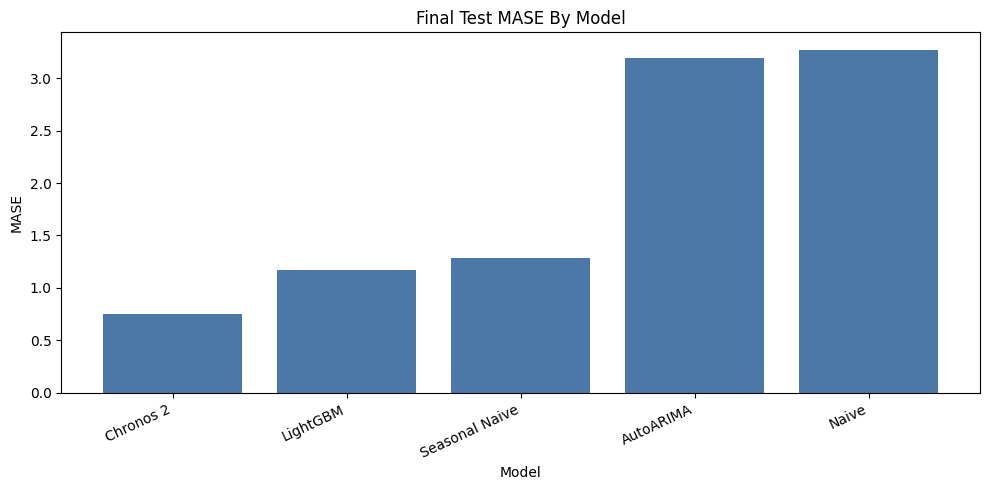

In [8]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_results["model"],
    final_results["MASE"],
    color="#4C78A8"
)

plt.title("Final Test MASE By Model")
plt.xlabel("Model")
plt.ylabel("MASE")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    FINAL_FIGURE_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# Best Model

The best model is selected as the model with the lowest test MASE.


In [9]:
best_model_summary = final_results.loc[[0], [
    "rank",
    "model",
    "MAE",
    "RMSE",
    "MASE"
]].copy()

best_model_summary


,rank,model,MAE,RMSE,MASE
0,1,Chronos 2,43.728676,75.270842,0.748726
